# HeteroGNN Graph Construction and Training
This notebook combines the graph construction (`build_graph.py`) and the GNN training (`train_gnn.py`) into a single workflow.


In [ ]:
%pip install torch torchvision torchaudio
%pip install torch-geometric
%pip install pandas numpy scipy networkx

## 1. Graph Construction
Extracting data from SQLite and OSMnx to build a PyG HeteroData graph.


In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import torch
import pickle
import os

from torch_geometric.data import HeteroData
from scipy.spatial import cKDTree


def build_graph(db_path, road_pkl_path, output_path):

    print("Connecting to database...")
    conn = sqlite3.connect(db_path)

    # ─────────────────────────────────────────────────────────────
    # 1. Load Places — only NON-LEAKY features
    # We deliberately exclude review-derived score components
    # (sentiment, rating, volume) because they directly encode the
    # composite_score target, causing trivial feature leakage.
    # Kept: lat, lng (geography) + open_hours, foot_traffic (external signals)
    # ─────────────────────────────────────────────────────────────
    print("Loading places...")

    places_df = pd.read_sql_query(
        (
            "SELECT p.place_id, p.latitude, p.longitude, "
            "p.foot_traffic_score_component, p.open_hours_score_component, "
            "p.composite_score "
            "FROM place p "
            "WHERE p.composite_score IS NOT NULL "
            "AND p.latitude IS NOT NULL "
            "AND p.longitude IS NOT NULL"
        ),
        conn
    )

    print(f"Loaded {len(places_df):,} places")

    fill_defaults = {
        "foot_traffic_score_component": 50.0,
        "open_hours_score_component":   50.0,
    }
    places_df = places_df.fillna(fill_defaults)

    place_id_to_idx = {
        pid: i
        for i, pid in enumerate(places_df["place_id"])
    }

    lat = places_df["latitude"].values.astype(float)
    lng = places_df["longitude"].values.astype(float)

    # ─────────────────────────────────────────────────────────────
    # Feature normalization  (4 features — NO leakage)
    # ─────────────────────────────────────────────────────────────

    lat_norm          = (lat - 27.7) / 0.1
    lng_norm          = (lng - 85.3) / 0.1
    open_hrs_norm     = places_df["open_hours_score_component"].values   / 100.0
    foot_traffic_norm = places_df["foot_traffic_score_component"].values / 100.0

    # Stack into [N, 4] feature matrix
    x_place = torch.tensor(
        np.column_stack([
            lat_norm,
            lng_norm,
            open_hrs_norm,
            foot_traffic_norm,
        ]),
        dtype=torch.float
    )

    # Target normalized to [0, 1]
    y_place = torch.tensor(
        places_df["composite_score"].values / 100.0,
        dtype=torch.float
    ).view(-1, 1)

    print(f"Place feature matrix: {x_place.shape}  (4 clean features, no leakage)")
    print(
        f"Score range: "
        f"{places_df['composite_score'].min():.1f} "
        f"to "
        f"{places_df['composite_score'].max():.1f}"
    )

    # ─────────────────────────────────────────────────────────────
    # 2. Load Categories
    # ─────────────────────────────────────────────────────────────
    print("Loading categories...")

    categories_df = pd.read_sql_query(
        (
            "SELECT DISTINCT category_name "
            "FROM categories_detailed "
            "WHERE category_name IS NOT NULL"
        ),
        conn
    )

    cat_to_idx = {
        cat: i
        for i, cat in enumerate(categories_df["category_name"])
    }

    x_category = torch.arange(
        len(cat_to_idx),
        dtype=torch.long
    ).view(-1, 1)

    print(f"{len(cat_to_idx):,} unique categories")

    place_cat_df = pd.read_sql_query(
        (
            "SELECT place_id, category_name "
            "FROM categories_detailed "
            "WHERE category_name IS NOT NULL"
        ),
        conn
    )

    place_cat_df = place_cat_df[
        place_cat_df["place_id"].isin(place_id_to_idx)
    ]

    edge_place_cat = torch.tensor(
        [
            [place_id_to_idx[p] for p in place_cat_df["place_id"]],
            [cat_to_idx[c]      for c in place_cat_df["category_name"]]
        ],
        dtype=torch.long
    )

    print(f"Place-Category edges: {edge_place_cat.shape[1]:,}")

    conn.close()

    # ─────────────────────────────────────────────────────────────
    # 3. Build HeteroData
    # ─────────────────────────────────────────────────────────────
    print("Constructing HeteroData...")

    data = HeteroData()

    data["place"].x         = x_place
    data["place"].y         = y_place
    data["place"].place_ids = list(places_df["place_id"])

    data["category"].x = x_category

    data["place", "has_category", "category"].edge_index     = edge_place_cat
    data["category", "rev_has_category", "place"].edge_index = edge_place_cat[[1, 0]]

    # ─────────────────────────────────────────────────────────────
    # 4. Load Road Graph
    # ─────────────────────────────────────────────────────────────
    print("Loading road graph...")

    if os.path.exists(road_pkl_path):

        with open(road_pkl_path, "rb") as f:
            G_road = pickle.load(f)

        road_nodes = list(G_road.nodes(data=True))

        road_id_to_idx = {node[0]: i for i, node in enumerate(road_nodes)}

        road_lats    = [(d.get("y", 27.7) - 27.7) / 0.1 for _, d in road_nodes]
        road_lngs    = [(d.get("x", 85.3) - 85.3) / 0.1 for _, d in road_nodes]
        street_cnts  = [min(d.get("street_count", 1), 8) / 8.0 for _, d in road_nodes]

        data["road_node"].x = torch.tensor(
            list(zip(road_lats, road_lngs, street_cnts)),
            dtype=torch.float
        )

        valid_edges = [
            (u, v) for u, v in G_road.edges()
            if u in road_id_to_idx and v in road_id_to_idx
        ]

        if valid_edges:
            src = [road_id_to_idx[u] for u, v in valid_edges]
            dst = [road_id_to_idx[v] for u, v in valid_edges]
            edge_road = torch.tensor([src, dst], dtype=torch.long)

            data["road_node", "connected_to",     "road_node"].edge_index = edge_road
            data["road_node", "rev_connected_to", "road_node"].edge_index = edge_road[[1, 0]]

        # Place -> nearest road nodes (k=100 with distance threshold)
        road_coords  = np.array([[d.get("y", 27.7), d.get("x", 85.3)] for _, d in road_nodes])
        place_coords = np.column_stack([lat, lng])

        kdtree = cKDTree(road_coords)
        k = min(100, len(road_nodes))
        dists, idxs = kdtree.query(place_coords, k=k)

        p_list, r_list = [], []
        MAX_ROAD_DIST_DEG = 0.005  # approx 500m
        for i in range(len(place_coords)):
            valid_mask = dists[i] <= MAX_ROAD_DIST_DEG
            valid_idxs = idxs[i][valid_mask]
            if len(valid_idxs) == 0:
                valid_idxs = [idxs[i][0]]
            for r_idx in valid_idxs:
                p_list.append(i)
                r_list.append(r_idx)

        edge_place_road = torch.tensor([p_list, r_list], dtype=torch.long)

        data["place",     "near",     "road_node"].edge_index = edge_place_road
        data["road_node", "rev_near", "place"].edge_index     = edge_place_road[[1, 0]]

        print(f"Road nodes: {len(road_nodes):,}, edges: {len(valid_edges):,}")

    else:
        print(f"WARNING: Road graph not found at {road_pkl_path} — skipping")

    print("\nFinal graph:")
    print(data)

    # ─────────────────────────────────────────────────────────────
    # 5. Save
    # ─────────────────────────────────────────────────────────────
    torch.save(data, output_path)

    torch.save(
        {"place_id_to_idx": place_id_to_idx, "cat_to_idx": cat_to_idx},
        output_path.replace(".pt", "_mappings.pt")
    )

    print(f"\nSaved to {output_path}")
    return data


# ─────────────────────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────────────────────

DB_PATH = os.path.join(os.getcwd(), "..", "DataEngineering", "ktm_all.db")

ROAD_PKL_PATH = os.path.join(
    os.getcwd(), "..", "DataEngineering",
    "road_graph_cache_osmnx_osmnx_valley.pkl"
)

OUT_PATH = os.path.join(os.getcwd(), "hetero_graph.pt")

data = build_graph(DB_PATH, ROAD_PKL_PATH, OUT_PATH)


## 2. Model Training
Defining the HeteroGNN (HeteroGAT) and training it via full-batch message passing.


Using device: cpu
HeteroData(
  place={
    x=[50312, 9],
    y=[50312, 1],
    place_ids=[50312],
  },
  category={ x=[2381, 1] },
  road_node={ x=[49426, 3] },
  (place, has_category, category)={ edge_index=[2, 67600] },
  (category, rev_has_category, place)={ edge_index=[2, 67600] },
  (road_node, connected_to, road_node)={ edge_index=[2, 124646] },
  (road_node, rev_connected_to, road_node)={ edge_index=[2, 124646] },
  (place, near, road_node)={ edge_index=[2, 251560] },
  (road_node, rev_near, place)={ edge_index=[2, 251560] }
)

Starting training (100 epochs, hidden=64, layers=2)...

Epoch 001 | Train Loss: 0.0693 | Val RMSE: 25.32 pts | LR: 0.00100
Epoch 010 | Train Loss: 0.0425 | Val RMSE: 21.37 pts | LR: 0.00100
Epoch 020 | Train Loss: 0.0144 | Val RMSE: 15.03 pts | LR: 0.00100
Epoch 030 | Train Loss: 0.0040 | Val RMSE: 5.78 pts | LR: 0.00100
Epoch 040 | Train Loss: 0.0030 | Val RMSE: 5.21 pts | LR: 0.00100
Epoch 050 | Train Loss: 0.0025 | Val RMSE: 4.52 pts | LR: 0.00100
Epo

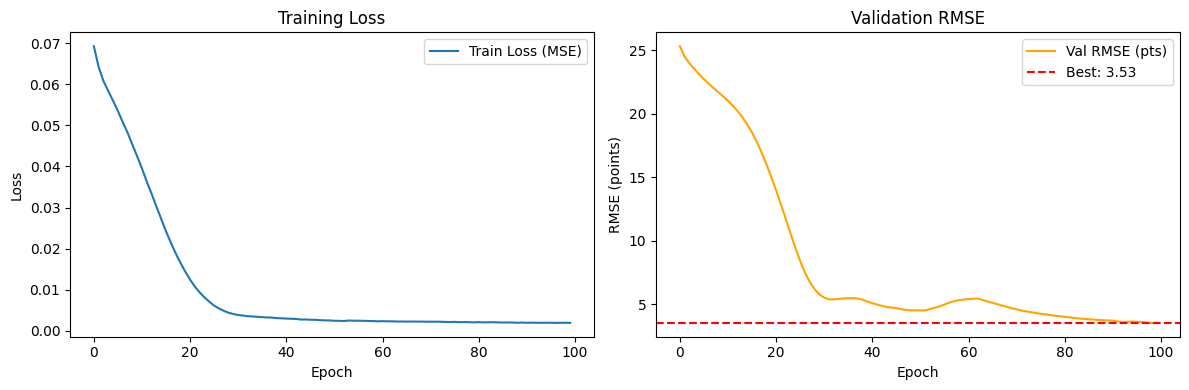

Saved training_curves.png


In [10]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv, Linear
import matplotlib.pyplot as plt


class HeteroGNN(torch.nn.Module):
    """
    Heterogeneous GNN using SAGEConv message passing.
    Lighter than HGTConv — no multi-head attention across all edge types.
    Processes: place, category, road_node.
    Predicts: composite_score for each place node.
    """
    def __init__(self, metadata, hidden_channels=64, out_channels=1, num_layers=2):
        super().__init__()

        # Input projection: each node type gets its own linear to hidden_channels
        self.input_proj = torch.nn.ModuleDict()
        self.input_proj['place']     = Linear(-1, hidden_channels)  # -1 = infer input dim
        self.input_proj['road_node'] = Linear(-1, hidden_channels)
        self.input_proj['category']  = torch.nn.Embedding(4000, hidden_channels)  # category index embed

        # HeteroConv layers: one per message-passing step
        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv({
                ('place',     'has_category',     'category'): SAGEConv((-1, -1), hidden_channels),
                ('category',  'rev_has_category', 'place'):    SAGEConv((-1, -1), hidden_channels),
                ('place',     'near',             'road_node'): SAGEConv((-1, -1), hidden_channels),
                ('road_node', 'rev_near',          'place'):    SAGEConv((-1, -1), hidden_channels),
                ('road_node', 'connected_to',     'road_node'): SAGEConv((-1, -1), hidden_channels),
                ('road_node', 'rev_connected_to', 'road_node'): SAGEConv((-1, -1), hidden_channels),
            }, aggr='sum')
            self.convs.append(conv)

        self.bn = torch.nn.BatchNorm1d(hidden_channels)  # stabilizes training
        self.dropout = torch.nn.Dropout(p=0.2)
        self.head = torch.nn.Sequential(
            Linear(hidden_channels, 32),
            torch.nn.ReLU(),
            Linear(32, out_channels),
            torch.nn.Sigmoid()  # output in [0, 1], multiply by 100 for score
        )

    def forward(self, x_dict, edge_index_dict):
        # Project each node type to hidden dim
        h = {}
        for node_type, x in x_dict.items():
            if node_type == 'category':
                h[node_type] = self.input_proj['category'](x.squeeze(-1))
            elif node_type in self.input_proj:
                h[node_type] = self.input_proj[node_type](x)
            else:
                h[node_type] = x  # passthrough if not projected

        # Message passing
        for i, conv in enumerate(self.convs):
            h = conv(h, edge_index_dict)
            h = {k: F.elu(v) for k, v in h.items()}

        # Apply BN + dropout to place embeddings only
        place_emb = self.bn(h['place'])
        place_emb = self.dropout(place_emb)

        return self.head(place_emb)


def train_model(graph_path='hetero_graph.pt', epochs=100, lr=0.001, hidden=64, layers=2):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load graph
    if not os.path.exists(graph_path):
        print(f"Graph not found at {graph_path} — run Cell 1 first")
        return
    data = torch.load(graph_path, weights_only=False)
    print(data)

    num_places = data['place'].num_nodes
    torch.manual_seed(42)
    perm      = torch.randperm(num_places)
    train_idx = perm[:int(0.8 * num_places)]
    val_idx   = perm[int(0.8 * num_places):int(0.9 * num_places)]
    test_idx  = perm[int(0.9 * num_places):]

    train_mask = torch.zeros(num_places, dtype=torch.bool)
    val_mask   = torch.zeros(num_places, dtype=torch.bool)
    test_mask  = torch.zeros(num_places, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx]     = True
    test_mask[test_idx]   = True

    data['place'].train_mask = train_mask
    data['place'].val_mask   = val_mask
    data['place'].test_mask  = test_mask
    data = data.to(device)

    model = HeteroGNN(
        metadata=data.metadata(),
        hidden_channels=hidden,
        out_channels=1,
        num_layers=layers
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5
    )


    x_dict = dict(data.x_dict)  # {node_type: feature_tensor}

    best_val_rmse = float('inf')
    train_losses, val_rmses = [], []

    print(f"\nStarting training ({epochs} epochs, hidden={hidden}, layers={layers})...\n")

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        optimizer.zero_grad()

        out = model(x_dict, data.edge_index_dict)  # [N, 1], in [0,1]

        y_true = data['place'].y  # already in [0,1] (composite/100)
        loss   = F.mse_loss(out[train_mask], y_true[train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent explosion
        optimizer.step()

        # ── Validate ──
        model.eval()
        with torch.no_grad():
            out_eval = model(x_dict, data.edge_index_dict)
            val_mse  = F.mse_loss(out_eval[val_mask], y_true[val_mask]).item()
            val_rmse = (val_mse ** 0.5) * 100.0  # back to 0-100 scale

        scheduler.step(val_mse)
        train_losses.append(loss.item())
        val_rmses.append(val_rmse)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            torch.save(model.state_dict(), 'best_hetero_gnn.pth')

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Val RMSE: {val_rmse:.2f} pts | LR: {optimizer.param_groups[0]["lr"]:.5f}')

    # ── Test ──
    model.load_state_dict(torch.load('best_hetero_gnn.pth', map_location=device))
    model.eval()
    with torch.no_grad():
        out_test = model(x_dict, data.edge_index_dict)
        test_mse  = F.mse_loss(out_test[test_mask], y_true[test_mask]).item()
        test_rmse = (test_mse ** 0.5) * 100.0
        test_mae  = F.l1_loss(out_test[test_mask], y_true[test_mask]).item() * 100.0

    print(f"\n{'='*50}")
    print(f"Best Val RMSE : {best_val_rmse:.2f} pts")
    print(f"Test RMSE     : {test_rmse:.2f} pts")
    print(f"Test MAE      : {test_mae:.2f} pts")
    print(f"{'='*50}")

    # ── Plot ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, label='Train Loss (MSE)')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Training Loss'); ax1.legend()
    ax2.plot(val_rmses, label='Val RMSE (pts)', color='orange')
    ax2.axhline(best_val_rmse, color='red', linestyle='--', label=f'Best: {best_val_rmse:.2f}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('RMSE (points)'); ax2.set_title('Validation RMSE'); ax2.legend()
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=120)
    plt.show()
    print("Saved training_curves.png")

    return model


model = train_model(
    graph_path='hetero_graph.pt',
    epochs=100,
    lr=0.001,
    hidden=64,
    layers=2
)

## 3. Testing the Trained Model
Let's load the trained weights and graph, and test a prediction for a hypothetical cafe location using the dynamic node injection strategy.

In [12]:
import torch
import numpy as np
from scipy.spatial import cKDTree

def predict_location(lat, lng, graph_path='hetero_graph.pt', model_path='best_hetero_gnn.pth'):
    """
    Predict suitability score for a lat/lng coordinate.
    Finds the nearest existing place in the graph and returns the model's prediction for it.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load graph + model
    data  = torch.load(graph_path, map_location=device, weights_only=False)
    model = HeteroGNN(metadata=data.metadata(), hidden_channels=64, out_channels=1, num_layers=2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Find nearest place node
    place_x  = data['place'].x.cpu().numpy()
    # Denormalize lat/lng from feature matrix
    place_lats = place_x[:, 0] * 0.1 + 27.7
    place_lngs = place_x[:, 1] * 0.1 + 85.3
    coords     = np.column_stack([place_lats, place_lngs])
    kdtree     = cKDTree(coords)

    dist_deg, idx = kdtree.query([[lat, lng]], k=1)
    idx = int(idx[0])
    dist_m = dist_deg[0] * 111_000  # rough degrees → meters

    # Run model on full graph
    x_dict = dict(data.x_dict)
    with torch.no_grad():
        out = model(x_dict, data.edge_index_dict)

    predicted_score = float(out[idx].item()) * 100.0
    predicted_score = max(0.0, min(100.0, predicted_score))
    actual_score    = float(data['place'].y[idx].item()) * 100.0

    print(f"Query:           ({lat}, {lng})")
    print(f"Nearest place:   index {idx}, {dist_m:.0f}m away")
    print(f"Actual score:    {actual_score:.2f} / 100")
    print(f"Predicted score: {predicted_score:.2f} / 100")
    print(f"Error:           {abs(predicted_score - actual_score):.2f} pts")

    return predicted_score


# Test with the same coordinates from the original notebook
predict_location(27.749976099999998, 85.3468032)

Query:           (27.749976099999998, 85.3468032)
Nearest place:   index 40032, 1m away
Actual score:    80.80 / 100
Predicted score: 79.01 / 100
Error:           1.79 pts


79.01475429534912